[**********************67%*******                ]  4 of 6 completed


Fetching data for: BIOCON.NS, PIDILITIND.NS, SIEMENS.NS, ETERNAL.NS, NATIONALUM.NS, ^NSEI


[*********************100%***********************]  6 of 6 completed


Data fetched successfully.

=== Daily Statistics (Returns, Variance, Std Dev) ===
               Mean Daily Return  Variance Daily  Std Dev Daily
BIOCON.NS               0.001231        0.000540       0.023244
PIDILITIND.NS          -0.000173        0.000170       0.013034
SIEMENS.NS              0.000174        0.000598       0.024453
ETERNAL.NS              0.000708        0.000700       0.026455
NATIONALUM.NS           0.000958        0.000835       0.028903
^NSEI                   0.000226        0.000079       0.008879

=== Covariance Matrix (Daily) ===
Ticker         BIOCON.NS  PIDILITIND.NS  SIEMENS.NS  ETERNAL.NS  NATIONALUM.NS
Ticker                                                                        
BIOCON.NS       0.000540       0.000064    0.000209    0.000143       0.000232
PIDILITIND.NS   0.000064       0.000170    0.000050    0.000073       0.000015
SIEMENS.NS      0.000209       0.000050    0.000598    0.000098       0.000320
ETERNAL.NS      0.000143       0.000073 

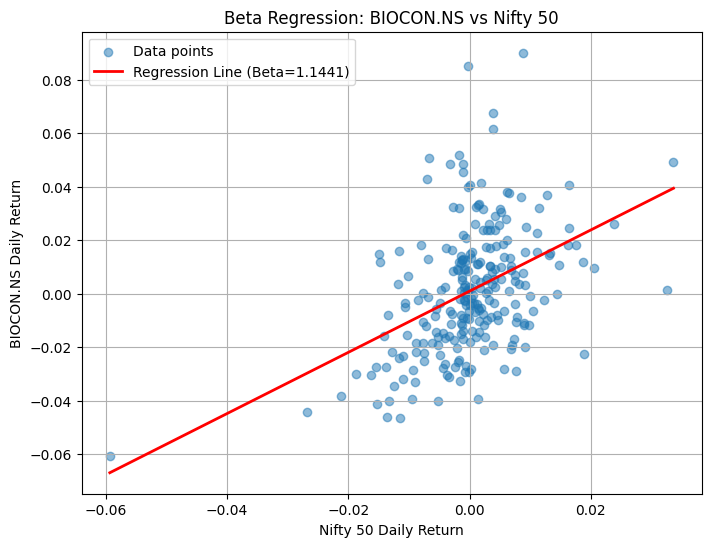

Saved plot: beta_BIOCON.png


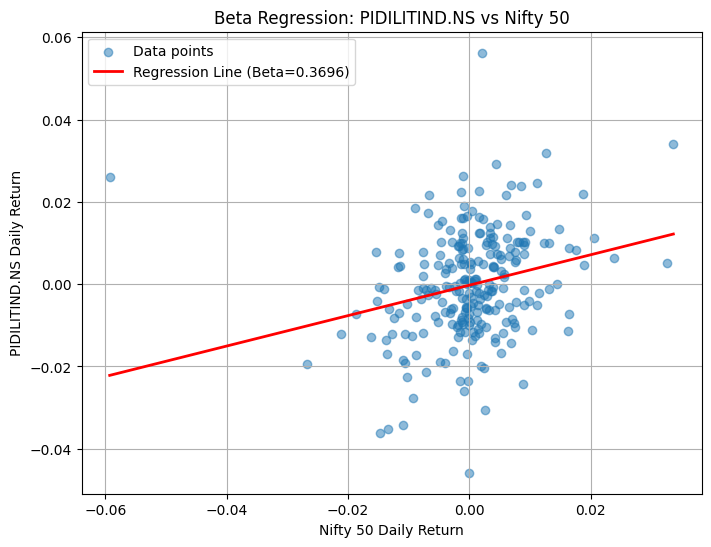

Saved plot: beta_PIDILITIND.png


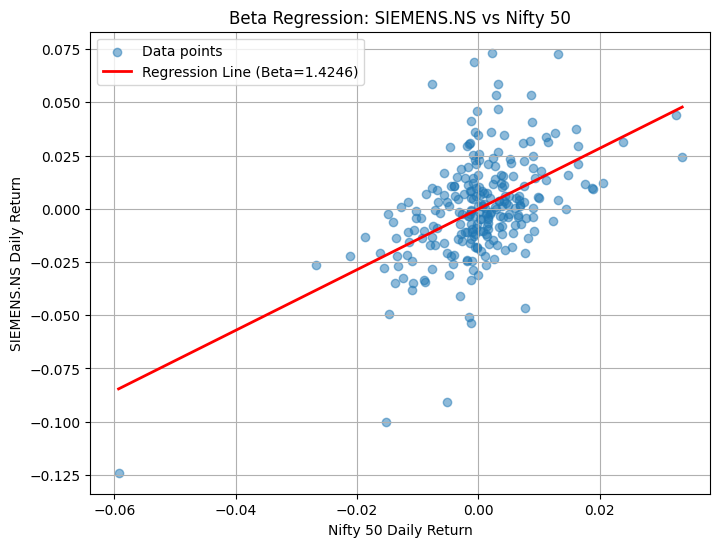

Saved plot: beta_SIEMENS.png


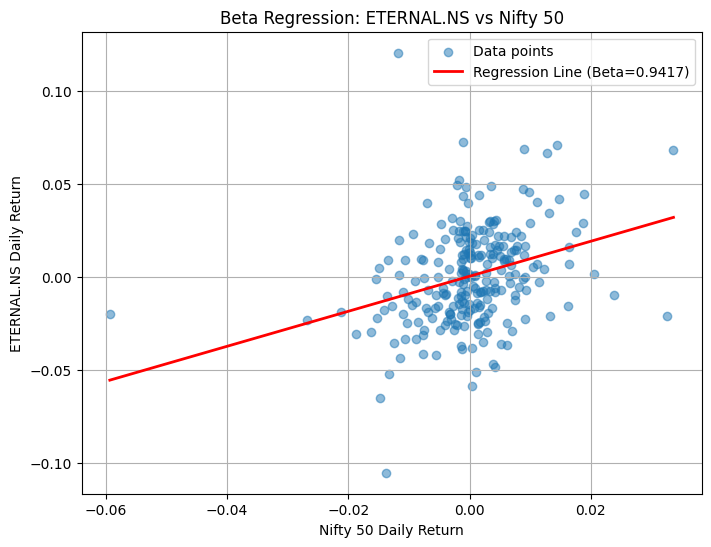

Saved plot: beta_ETERNAL.png


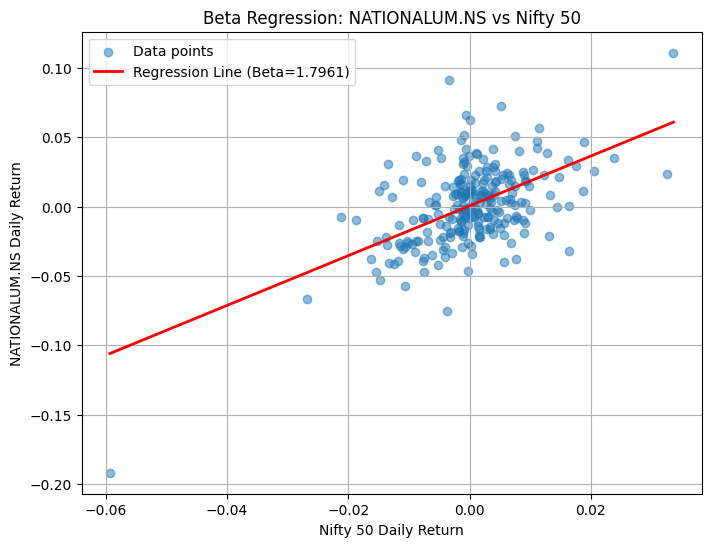

Saved plot: beta_NATIONALUM.png

Annualized Nifty 50 Return: 5.69%

CAPM Summary:
BIOCON.NS: Beta = 1.1441 | Historical Annual Return = 31.02% | CAPM Required Return = 5.53%
PIDILITIND.NS: Beta = 0.3696 | Historical Annual Return = -4.35% | CAPM Required Return = 6.39%
SIEMENS.NS: Beta = 1.4246 | Historical Annual Return = 4.38% | CAPM Required Return = 5.22%
ETERNAL.NS: Beta = 0.9417 | Historical Annual Return = 17.83% | CAPM Required Return = 5.75%
NATIONALUM.NS: Beta = 1.7961 | Historical Annual Return = 24.13% | CAPM Required Return = 4.80%

=== Domestic Portfolio Optimization (No Short Selling) ===
Optimizing Tangency Portfolio...
Optimizing Min Variance Portfolio...


[*********************100%***********************]  6 of 6 completed

Optimizing Tangency Portfolio...
Tangency Portfolio: Return = 28.38%, Volatility = 31.58%
Tangency Weights:
                Weight %
BIOCON.NS         72.12
PIDILITIND.NS      0.00
SIEMENS.NS         0.00
ETERNAL.NS        11.44
NATIONALUM.NS     16.44

=== International Portfolio Optimization ===

Fetching data for: BIOCON.NS, PIDILITIND.NS, SIEMENS.NS, ETERNAL.NS, NATIONALUM.NS, SPOT
Data fetched successfully.
Optimizing Tangency Portfolio...
Optimizing Min Variance Portfolio...


Optimizing Tangency Portfolio...
Tangency Portfolio: Return = 62.42%, Volatility = 29.52%
Tangency Weights:
                Weight %
BIOCON.NS         17.16
PIDILITIND.NS      5.39
SIEMENS.NS        11.04
ETERNAL.NS         0.00
NATIONALUM.NS      0.00
SPOT              66.41

International vs Domestic Tangency: Int Return 62.42% (Dom 28.38%), Int Vol 29.52% (Dom 31.58%)
vs Nifty 50: Return 5.69%, Vol 14.10%

=== End of Analysis ===


In [ ]:
# Risk-free rate: 6.8% from RBI T-bill data

import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize as sc_minimize
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# fetching stock data
def getData(tickers, start, end):
    print(f"\nFetching data for: {', '.join(tickers)}")
    try:
        data = yf.download(tickers, start=start, end=end)['Close']
        if data.empty:
            raise ValueError("No data fetched. Check ticker symbols and date range.")
        data = data.ffill().dropna()  #filling missing prices and drop rows with NaN
        print("Data fetched successfully.")
        returns = data.pct_change().dropna()  # Calculate daily returns
        return returns
    except Exception as e:
        print(f"Error fetching data: {e}")
        return None


start_date = '2024-04-01'
end_date = '2025-03-31'
risk_free_rate_annual = 0.068  # 6.8% approx avg T-bill rate

# Our stocks:
stocks = ['BIOCON.NS', 'PIDILITIND.NS', 'SIEMENS.NS', 'ETERNAL.NS', 'NATIONALUM.NS']
index_ticker = '^NSEI'  # Nifty 50
international = 'SPOT'  # Spotify as international

all_tickers_dom = stocks + [index_ticker]

# Getting domestic data + index
returns_dom = getData(all_tickers_dom, start_date, end_date)
if returns_dom is None:
    print("Failed to fetch data. Exiting.")
    exit(1)
else:
    stock_returns = returns_dom[stocks]
    index_returns = returns_dom[index_ticker]

    # Calculating daily stats
    mean_daily_stocks = stock_returns.mean()
    var_daily_stocks = stock_returns.var()
    sd_daily_stocks = stock_returns.std()

    mean_daily_index = index_returns.mean()
    var_daily_index = index_returns.var()
    sd_daily_index = index_returns.std()

    # Combine into DF
    stats_df = pd.DataFrame({
        'Mean Daily Return': pd.concat([mean_daily_stocks, pd.Series([mean_daily_index], index=[index_ticker])]),
        'Variance Daily': pd.concat([var_daily_stocks, pd.Series([var_daily_index], index=[index_ticker])]),
        'Std Dev Daily': pd.concat([sd_daily_stocks, pd.Series([sd_daily_index], index=[index_ticker])])
    })
    print("\n=== Daily Statistics (Returns, Variance, Std Dev) ===")
    print(stats_df.round(6))
    # stats_df.to_csv('stats.csv')  # Save for Excel if needed

    # Cov and Corr matrices (only for stocks)
    cov_matrix = stock_returns.cov()
    corr_matrix = stock_returns.corr()
    print("\n=== Covariance Matrix (Daily) ===")
    print(cov_matrix.round(6))
    print("\n=== Correlation Matrix ===")
    print(corr_matrix.round(4))
    cov_matrix.to_csv('cov.csv')
    corr_matrix.to_csv('corr.csv')

    # Betas and CAPM - loop through each stock
    print("\n=== Beta Regressions and CAPM ===")
    betas = {}
    annual_means_hist = {}
    capm_returns = {}
    beta_data = []
    for stock in stocks:
        # Regression: stock returns vs index (with constant)
        X = sm.add_constant(index_returns)
        y = stock_returns[stock]
        model = sm.OLS(y, X).fit()
        beta = model.params[1]  # Slope is beta
        betas[stock] = beta
        annual_mean_hist = y.mean() * 252  # Annualize
        annual_means_hist[stock] = annual_mean_hist

        # CAPM: Rf + beta * (Rm - Rf)
        market_premium = (index_returns.mean() * 252) - risk_free_rate_annual
        req_return = risk_free_rate_annual + beta * market_premium
        capm_returns[stock] = req_return

        beta_data.append({
            'Stock': stock.replace('.NS', ''),
            'Beta': beta,
            'Historical Annual Return (%)': annual_mean_hist * 100,
            'CAPM Required Return (%)': req_return * 100
        })

        # Plotting beta regression
        plt.figure(figsize=(8, 6))
        plt.scatter(index_returns, y, alpha=0.5, label='Data points')
        x_line = np.linspace(index_returns.min(), index_returns.max(), 100)
        y_line = model.params[0] + model.params[1] * x_line  # Regression line
        plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Regression Line (Beta={beta:.4f})')
        plt.xlabel('Nifty 50 Daily Return')
        plt.ylabel(f'{stock} Daily Return')
        plt.title(f'Beta Regression: {stock} vs Nifty 50')
        plt.legend()
        plt.grid(True)
        plt.savefig(f'beta_{stock.replace(".NS", "")}.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"Saved plot: beta_{stock.replace('.NS', '')}.png")

    # Nifty annual return
    annual_index_mean = index_returns.mean() * 252
    print(f"\nAnnualized Nifty 50 Return: {annual_index_mean * 100:.2f}%")
    print("\nCAPM Summary:")
    for stock in stocks:
        hist_annual_pct = annual_means_hist[stock] * 100
        capm_pct = capm_returns[stock] * 100
        print(f"{stock}: Beta = {betas[stock]:.4f} | Historical Annual Return = {hist_annual_pct:.2f}% | CAPM Required Return = {capm_pct:.2f}%")

    beta_df = pd.DataFrame(beta_data)
    beta_df.to_csv('betas_capm.csv', index=False)

# Portfolio calc functions
def portfolioPerformance(weights, meanReturns_daily, covMatrix_daily):
    # Annual return and std
    port_return = np.sum(meanReturns_daily * weights) * 252
    port_std = np.sqrt(np.dot(weights.T, np.dot(covMatrix_daily * 252, weights)))
    return port_return, port_std

def negativeSR(weights, meanReturns_daily, covMatrix_daily, riskFreeRate):
    # Negative Sharpe for minimization
    p_ret, p_std = portfolioPerformance(weights, meanReturns_daily, covMatrix_daily)
    return -((p_ret - riskFreeRate) / p_std)

def maxSR(meanReturns_daily, covMatrix_daily, riskFreeRate, constraintSet=(0, 1)):
    numAssets = len(meanReturns_daily)
    args = (meanReturns_daily, covMatrix_daily, riskFreeRate)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple(constraintSet for _ in range(numAssets))
    print("Optimizing Tangency Portfolio...")
    result = sc_minimize(negativeSR, numAssets * [1. / numAssets], args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    if not result.success:
        print(f"Optimization failed: {result.message}")
        # Fallback to equal weights if fails
        return type('obj', (object,), {'x': np.ones(numAssets)/numAssets, 'success': False})()
    return result

def portfolioVariance(weights, meanReturns_daily, covMatrix_daily):
    # Variance for min vol opt
    _, port_std = portfolioPerformance(weights, meanReturns_daily, covMatrix_daily)
    return port_std ** 2

def minimizeVariance(meanReturns_daily, covMatrix_daily, constraintSet=(0, 1)):
    numAssets = len(meanReturns_daily)
    args = (meanReturns_daily, covMatrix_daily)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple(constraintSet for _ in range(numAssets))
    print("Optimizing Min Variance Portfolio...")
    result = sc_minimize(portfolioVariance, numAssets * [1. / numAssets], args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    if not result.success:
        print(f"Optimization failed: {result.message}")
        # Fallback
        return type('obj', (object,), {'x': np.ones(numAssets)/numAssets, 'success': False})()
    return result

def efficientOpt(meanReturns_daily, covMatrix_daily, target_return_annual, constraintSet=(0,1)):
    numAssets = len(meanReturns_daily)
    target_daily = target_return_annual / 252  # Note: 252 trading days
    args = (meanReturns_daily, covMatrix_daily)
    constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(meanReturns_daily * x) - target_daily},
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    )
    bounds = tuple(constraintSet for _ in range(numAssets))
    result = sc_minimize(portfolioVariance, numAssets*[1./numAssets], args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    if result.success:
        return result.x
    return None  # If fails, skip point

def plotEF(meanReturns_daily, covMatrix_daily, riskFreeRate, title, index_ret_annual=None, index_std_annual=None):
    # Calculate tangency and min vol
    tangency_res = maxSR(meanReturns_daily, covMatrix_daily, riskFreeRate)
    tangency_weights = tangency_res.x
    tangency_ret, tangency_std = portfolioPerformance(tangency_weights, meanReturns_daily, covMatrix_daily)

    minvol_res = minimizeVariance(meanReturns_daily, covMatrix_daily)
    minvol_weights = minvol_res.x
    minvol_ret, minvol_std = portfolioPerformance(minvol_weights, meanReturns_daily, covMatrix_daily)

    # Generate EF points
    target_returns = np.linspace(minvol_ret, tangency_ret, 50)
    eff_stds = []
    for tgt in target_returns:
        weights = efficientOpt(meanReturns_daily, covMatrix_daily, tgt)
        if weights is not None:
            _, std = portfolioPerformance(weights, meanReturns_daily, covMatrix_daily)
            eff_stds.append(std)
        else:
            eff_stds.append(np.nan)  # Skip invalid

    # Plot with Plotly
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=np.array(eff_stds)*100, y=np.array(target_returns)*100,
                             mode='lines', name='Efficient Frontier',
                             line=dict(color='black', width=2)))
    fig.add_trace(go.Scatter(x=[tangency_std*100], y=[tangency_ret*100],
                             mode='markers+text', name='Tangency Portfolio',
                             marker=dict(color='red', size=12),
                             text=[f'({tangency_std*100:.1f}%, {tangency_ret*100:.1f}%)'],
                             textposition="top center"))
    fig.add_trace(go.Scatter(x=[minvol_std*100], y=[minvol_ret*100],
                             mode='markers', name='Min Vol Portfolio',
                             marker=dict(color='blue', size=10)))
    fig.add_trace(go.Scatter(x=[0, tangency_std*100], y=[riskFreeRate*100, tangency_ret*100],
                             mode='lines', name='CML',
                             line=dict(color='green', dash='dash')))
    fig.add_trace(go.Scatter(x=[0], y=[riskFreeRate*100],
                             mode='markers', name='Risk-Free Rate',
                             marker=dict(color='green', size=8, symbol='triangle-up'),
                             text=[f'({riskFreeRate*100:.1f}%)'], textposition="middle right"))

    # Add Nifty point
    if index_ret_annual is not None and index_std_annual is not None:
        fig.add_trace(go.Scatter(x=[index_std_annual*100], y=[index_ret_annual*100],
                                 mode='markers', name='Nifty 50',
                                 marker=dict(color='orange', size=10)))

    fig.update_layout(title=title,
                      xaxis_title='Annualized Volatility (%)',
                      yaxis_title='Annualized Expected Return (%)',
                      showlegend=True, width=800, height=600)
    fig.show()  # Show interactive plot

# Index as single asset performance
index_mean_daily = index_returns.mean()
index_var_daily = index_returns.var()
index_ret_annual, index_std_annual = portfolioPerformance(np.array([1.0]), np.array([index_mean_daily]), np.array([[index_var_daily]]))

# Domestic optimization
print("\n=== Domestic Portfolio Optimization (No Short Selling) ===")
mean_daily_dom = stock_returns.mean().values  # Convert to numpy array
cov_daily_dom = stock_returns.cov().values
plotEF(mean_daily_dom, cov_daily_dom, risk_free_rate_annual,
       'Markowitz Efficient Frontier - Domestic (5 Indian Stocks)', index_ret_annual, index_std_annual)

# Get tangency details
tangency_dom = maxSR(mean_daily_dom, cov_daily_dom, risk_free_rate_annual)
tangency_weights_dom = tangency_dom.x
tang_ret_dom, tang_std_dom = portfolioPerformance(tangency_weights_dom, mean_daily_dom, cov_daily_dom)
print(f"Tangency Portfolio: Return = {tang_ret_dom*100:.2f}%, Volatility = {tang_std_dom*100:.2f}%")
alloc_dom = pd.DataFrame({'Weight %': (tangency_weights_dom * 100).round(2)}, index=stocks)
print("Tangency Weights:\n", alloc_dom)

# International optimization
print("\n=== International Portfolio Optimization ===")
int_tickers = stocks + [international]
returns_int = getData(int_tickers, start_date, end_date)
if returns_int is not None:
    mean_daily_int = returns_int.mean().values
    cov_daily_int = returns_int.cov().values
    plotEF(mean_daily_int, cov_daily_int, risk_free_rate_annual,
           f'Markowitz Efficient Frontier - International (+ {international})', index_ret_annual, index_std_annual)

    # Tangency for intl
    tangency_int = maxSR(mean_daily_int, cov_daily_int, risk_free_rate_annual)
    tangency_weights_int = tangency_int.x
    tang_ret_int, tang_std_int = portfolioPerformance(tangency_weights_int, mean_daily_int, cov_daily_int)
    print(f"Tangency Portfolio: Return = {tang_ret_int*100:.2f}%, Volatility = {tang_std_int*100:.2f}%")
    alloc_int = pd.DataFrame({'Weight %': (tangency_weights_int * 100).round(2)}, index=int_tickers)
    print("Tangency Weights:\n", alloc_int)

    # Quick comparison
    print(f"\nInternational vs Domestic Tangency: Int Return {tang_ret_int*100:.2f}% (Dom {tang_ret_dom*100:.2f}%), Int Vol {tang_std_int*100:.2f}% (Dom {tang_std_dom*100:.2f}%)")
    print(f"vs Nifty 50: Return {index_ret_annual*100:.2f}%, Vol {index_std_annual*100:.2f}%")

print("\n=== End of Analysis ===")